### Download data

In [ ]:
import os
#os.system('ls -l')

# Download Experiment Infos
os.system('aws s3 cp s3://natural-scenes-dataset/nsddata/experiments/nsd/nsd_expdesign.mat nsddata/experiments/nsd/')
os.system('aws s3 cp s3://natural-scenes-dataset/nsddata/experiments/nsd/nsd_stim_info_merged.pkl nsddata/experiments/nsd/')

# Download Stimuli
os.system('aws s3 cp s3://natural-scenes-dataset/nsddata_stimuli/stimuli/nsd/nsd_stimuli.hdf5 nsddata_stimuli/stimuli/nsd/')

# Download Betas
for sub in [1,2,5,7]:
    for sess in range(1,40):
        os.system('aws s3 cp s3://natural-scenes-dataset/nsddata_betas/ppdata/subj{:02d}/func1pt8mm/betas_fithrf_GLMdenoise_RR/betas_session{:02d}.nii.gz nsddata_betas/ppdata/subj{:02d}/func1pt8mm/betas_fithrf_GLMdenoise_RR/'.format(sub,sess,sub))

# Download ROIs
for sub in [1,2,5,7]:
    os.system('aws s3 cp s3://natural-scenes-dataset/nsddata/ppdata/subj{:02d}/func1pt8mm/roi/* nsddata/ppdata/subj{:02d}/func1pt8mm/roi/'.format(sub,sub))


fatal error: Unable to locate credentials
fatal error: Unable to locate credentials


### Balloon-Windkessel model

In [ ]:
import nibabel as nib

# Load atlas
atlas_path = 'models/neurolib/examples/data/AAL2_atlas_data/AAL2.nii'
atlas_img = nib.load(atlas_path)
atlas_data = atlas_img.get_fdata()  # Shape: (X, Y, Z), values: 0 to 120

In [ ]:
atlas_data.shape 

(91, 109, 91)

In [ ]:
import sys
import numpy as np 
sys.path.insert(0, '/media/hung/data1/codes/imge2fmri/models/neurolib')



from neurolib.models.bold.model import BOLDModel

def generate_synthetic_neural_activity(n_regions, n_timesteps, activity_pattern='random'):
    baseline = 10.0 # Hz
    activity = np.random.randn(n_regions, n_timesteps) * 2.0
    activity = np.maximum(activity, 0) # Firing rates can't be negative
    
    activity[:40, 4000:6000] += 15.0
    return activity 


# run BOLD model
n_regions = 120
n_timesteps = 10000


neural_activity = generate_synthetic_neural_activity(n_regions, n_timesteps)
bold_model = BOLDModel(N=n_regions, dt=1.0)
bold_model.run(neural_activity)
bold_signal = bold_model.BOLD

In [13]:
print(f"Neural activity: {neural_activity.shape}, range: {neural_activity.min():.1f}-{neural_activity.max():.1f} Hz")
print(f"BOLD signal: {bold_signal.shape}, range: {bold_signal.min():.4f}-{bold_signal.max():.4f}")

Neural activity: (120, 10000), range: 0.0-23.9 Hz
BOLD signal: (120, 5), range: 0.0000-0.0623


### NSD data

In [ ]:
import scipy.io as sio
expdesign = sio.loadmat('data/NSD/data/nsddata/experiments/nsd/nsd_expdesign.mat')

print(expdesign.keys())

dict_keys(['__header__', '__version__', '__globals__', 'basiccnt', 'masterordering', 'sharedix', 'stimpattern', 'subjectim'])


In [20]:
print(expdesign['subjectim'][0])

[ 2951  2991  3050 ... 19472 49508 11124]


In [23]:
expdesign['subjectim'][0].shape

(10000,)

In [28]:
import h5py

file_path = 'data/NSD/data/nsddata_stimuli/stimuli/nsd/nsd_stimuli.hdf5'
with h5py.File(file_path, 'r') as f:
    for key in f.keys():
        print(f"{key}: {f[key].shape}")


imgBrick: (73000, 425, 425, 3)


(425, 425, 3)


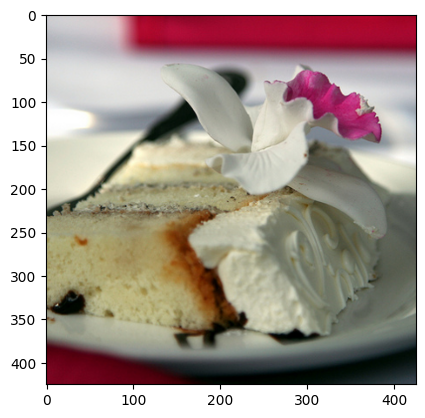

In [ ]:
import h5py 
import matplotlib.pyplot as plt

subject_idx = 1
trial_idx = 1
img_id = expdesign['subjectim'][subject_idx, trial_idx]

with h5py.File("data/NSD/data/nsddata_stimuli/stimuli/nsd/nsd_stimuli.hdf5", 'r') as f:
    image = f['imgBrick'][img_id]

print(image.shape)
plt.imshow(image)
plt.show()


In [1]:
import nibabel as nib

file_path = 'data/NSD/data/nsddata_timeseries/ppdata/subj01/func1pt8mm/timeseries/timeseries_nsdimagery_run01.nii.gz'
img = nib.load(file_path)
print(img.shape)


(81, 104, 83, 240)


In [ ]:

import nibabel as nib
import os

file_path = 'data/NSD/data/nsddata_timeseries/ppdata/subj01/func1pt8mm/timeseries/timeseries_session01_run01.nii.gz'
if os.path.exists(file_path):
    img = nib.load(file_path)
    print(f"Shape of {os.path.basename(file_path)}: {img.shape}")
else:
    print(f"File not found: {file_path}")

### Syn-Brain playground

In [ ]:
!python SynBrain/data/prepare_nsddata_scale.py --sub 1 --data_path /media/hung/data1/codes/imge2fmri/data/NSD